In [112]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import convolve, Gaussian2DKernel
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit
import pandas as pd
from scipy import interpolate
from fancy_colorbar import plot_colorbar

from copy import deepcopy
from glob import glob
from scipy.interpolate import RegularGridInterpolator

In [2]:
raster_files = sorted(glob("../../src/full_detector/level2/2022/10/24/*.fits"))
raster_files

['../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221629_V04_150995397-000.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221815_V04_150995397-001.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222001_V04_150995397-002.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222148_V04_150995397-003.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222334_V04_150995397-004.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222519_V04_150995397-005.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222705_V04_150995397-006.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222851_V04_150995397-007.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T223037_V04_150995397-008.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spi

In [3]:
test_raster_cube = read_spice_l2_fits(raster_files[0])

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-09-09 13:27:21 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74638738770 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'. [astropy.wcs.wcs]
2025-09-09 13:27:21 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.928116 from DATEREF.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'.
keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-09-09 13:27:21 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74638738770 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.928

In [4]:
test_raster_cube.keys()

dict_keys(['Full SW 4:1 Focal Lossy', 'Full LW 4:1 Focal Lossy'])

In [5]:
test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape

(1, 1024, 1024, 1)

In [6]:
sw_data = np.ones((test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[1],
                   test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[2],
                   len(raster_files)))*np.nan

lw_data = np.ones((test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[1],
                     test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[2],
                     len(raster_files)))*np.nan

sw_wcs_list = []
lw_wcs_list = []
sw_meta_list = []
lw_meta_list = []
sw_wvl_list = []
lw_wvl_list = []

for ii, file_ in enumerate(raster_files):
    datacube_ = read_spice_l2_fits(file_)
    sw_data[:,:,ii] = datacube_['Full SW 4:1 Focal Lossy'].data[0,:,:,0]
    lw_data[:,:,ii] = datacube_['Full LW 4:1 Focal Lossy'].data[0,:,:,0]
    sw_wcs_list.append(datacube_['Full SW 4:1 Focal Lossy'].wcs)
    lw_wcs_list.append(datacube_['Full LW 4:1 Focal Lossy'].wcs)
    sw_meta_list.append(datacube_['Full SW 4:1 Focal Lossy'].meta)
    lw_meta_list.append(datacube_['Full LW 4:1 Focal Lossy'].meta)
    sw_wvl_list.append(datacube_['Full SW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
    lw_wvl_list.append(datacube_['Full LW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
sw_data = np.flip(sw_data, axis=-1)
lw_data = np.flip(lw_data, axis=-1)

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-09-09 13:27:21 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74638738770 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'. [astropy.wcs.wcs]
2025-09-09 13:27:21 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.928116 from DATEREF.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'.
keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-09-09 13:27:21 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74638738770 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.928

In [7]:
crval1_array = np.zeros(len(raster_files))
crval2_array = np.zeros(len(raster_files))
for ii in range(len(raster_files)):
    crval1_array[ii] = sw_meta_list[ii]["CRVAL1"]
    crval2_array[ii] = sw_meta_list[ii]["CRVAL2"]
    

In [8]:
cdelt1_array = np.sqrt((crval1_array[1:] - crval1_array[:-1])**2 + (crval2_array[1:] - crval2_array[:-1])**2)

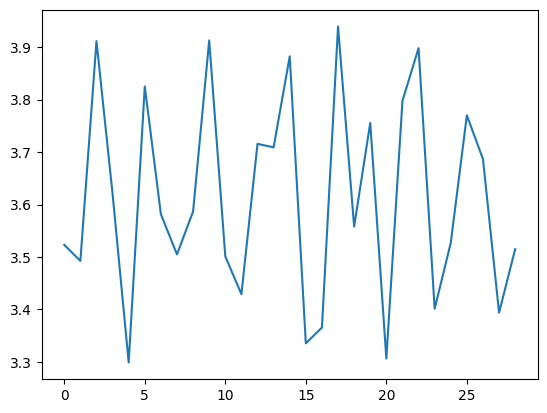

In [9]:
plt.plot(cdelt1_array)

In [10]:
plot_aspect = sw_meta_list[0]["CDELT2"]/np.nanmean(cdelt1_array)

In [11]:
sw_data.shape

(1024, 1024, 30)

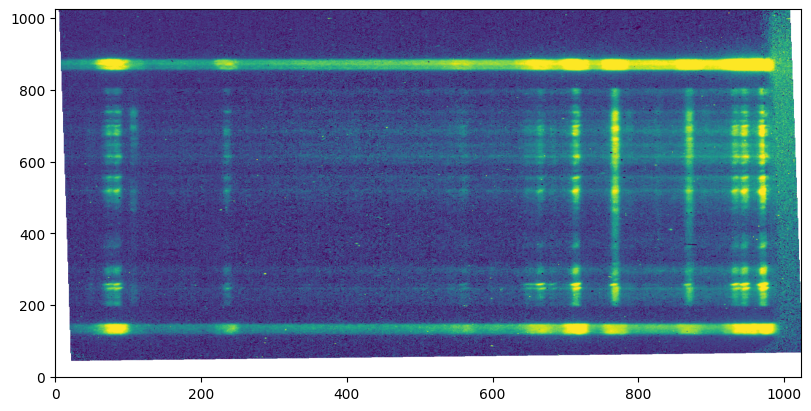

In [12]:
fig, ax = plt.subplots(figsize=(8,4),layout="constrained")
ax.imshow(sw_data[:,:,0].T, origin='lower',
          norm=ImageNormalize(vmin=np.nanpercentile(sw_data[:,:,0], 1),
                                vmax=np.nanpercentile(sw_data[:,:,0], 99),
                                stretch=AsinhStretch()),
                                aspect='auto')

/scratch/tmp.42163065.zhuyin/ipykernel_99714/1899417282.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')


(768.0, 772.0)

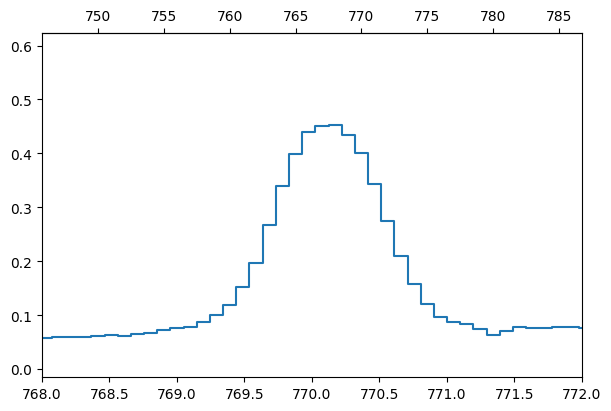

In [13]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

ax.set_xlim(768,772)

In [14]:
NeVIII_770_intmap = np.nanmean(sw_data[746:786,210:790,:], axis=0) - np.nanmean(sw_data[np.r_[746:752,780:786],210:790,:], axis=0)

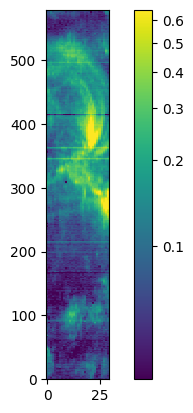

In [15]:
fig, ax = plt.subplots()
im = ax.imshow(NeVIII_770_intmap, origin='lower', aspect=plot_aspect,
        norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_770_intmap, 1),
                            vmax=np.nanpercentile(NeVIII_770_intmap, 99),
                            stretch=AsinhStretch()),
        interpolation="none")
plt.colorbar(im)

/scratch/tmp.42163065.zhuyin/ipykernel_99714/1557561603.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')


(704.0, 708.0)

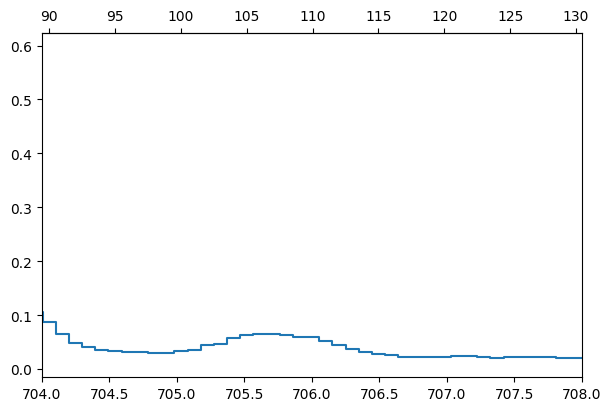

In [16]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,0], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

ax.set_xlim(704,708)

In [17]:
MgIX_706_intmap = np.nanmean(sw_data[100:130,210:790,:], axis=0) - np.nanmean(sw_data[np.r_[95:100,120:130],210:790,:], axis=0)

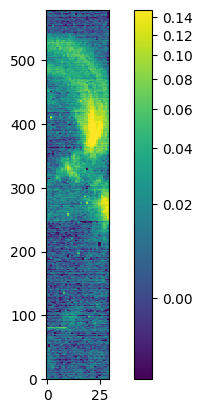

In [18]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_706_intmap, origin='lower', aspect=plot_aspect,
        norm=ImageNormalize(vmin=np.nanpercentile(MgIX_706_intmap, 1),
                            vmax=np.nanpercentile(MgIX_706_intmap, 99),
                            stretch=AsinhStretch()),
        interpolation="none")
plt.colorbar(im)

In [19]:
MgIX_706_fitmodel = SpectrumFit2D(
    data = sw_data[100:130,210:790,:].transpose(1,2,0),
    wvl = sw_wvl_list[0][100:130],
    line_number=1,
    line_wvl_init=[706.06],
    int_max_init=[0.05],
    fwhm_init=0.5,
    same_width=True,
)

MgIX_706_fitmodel.run_lse_mp(ncpu=5, prev_init=False)

/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fittin

In [20]:
MgIX_706_fitmodel.int_total_fit.shape

(580, 30, 1)

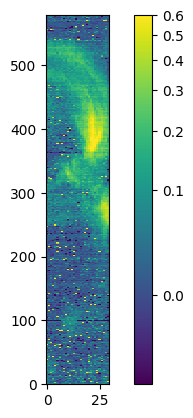

In [21]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_706_fitmodel.int_total_fit[:,:,0], origin='lower', aspect=plot_aspect,
        norm=ImageNormalize(vmin=np.nanpercentile(MgIX_706_fitmodel.int_total_fit, 1),
                            vmax=np.nanpercentile(MgIX_706_fitmodel.int_total_fit, 99),
                            stretch=AsinhStretch()),
        interpolation="none")
plt.colorbar(im)

/scratch/tmp.42163065.zhuyin/ipykernel_99714/71989274.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,1], axis=1), where='mid')


(0.01098958052130902, 0.1)

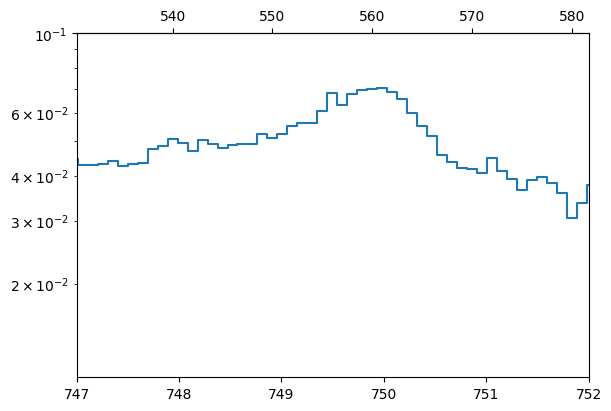

In [22]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,210:790,1], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

ax.set_xlim(747,752)
ax.set_yscale("log")
ax.set_ylim(top=0.1)

In [23]:
MgIX_749_SIV_750_intmap = np.nanmean(sw_data[550:570,210:790,:], axis=0)# - np.nanmean(sw_data[np.r_[95:100,120:130],210:790,:], axis=0)

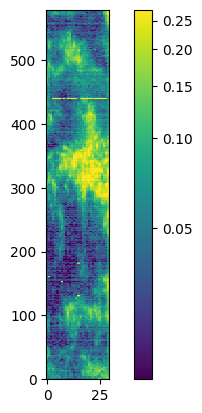

In [25]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_749_SIV_750_intmap, origin='lower', aspect=plot_aspect,
        norm=ImageNormalize(vmin=np.nanpercentile(MgIX_749_SIV_750_intmap, 1),
                            vmax=np.nanpercentile(MgIX_749_SIV_750_intmap, 99),
                            stretch=AsinhStretch()),
        interpolation="none")
plt.colorbar(im)

In [26]:
MgIX_749_SIV_750_fitmodel = SpectrumFit2D(
    data = sw_data[545:575,210:790,:].transpose(1,2,0),
    wvl = sw_wvl_list[0][545:575],
    line_number=2,
    line_wvl_init=[749.552,750.221],
    int_max_init=[0.05,0.05],
    fwhm_init=0.5,
    same_width=True,
)

In [27]:
MgIX_749_SIV_750_fitmodel.run_lse_mp(ncpu=5, prev_init=False)

/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fittin

In [28]:
MgIX_749_SIV_750_fitmodel.int_total_fit.shape

(580, 30, 2)

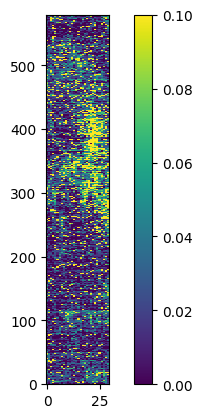

In [29]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_749_SIV_750_fitmodel.int_total_fit[:,:,0], origin='lower', aspect=plot_aspect,
vmin=0,vmax=0.1, interpolation="none")
plt.colorbar(im)

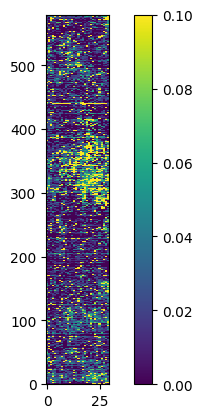

In [30]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_749_SIV_750_fitmodel.int_total_fit[:,:,1], origin='lower', aspect=plot_aspect,
vmin=0,vmax=0.1, interpolation="none")
plt.colorbar(im)

/scratch/tmp.42163065.zhuyin/ipykernel_99714/976739085.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,610:650,20], axis=1), where='mid')


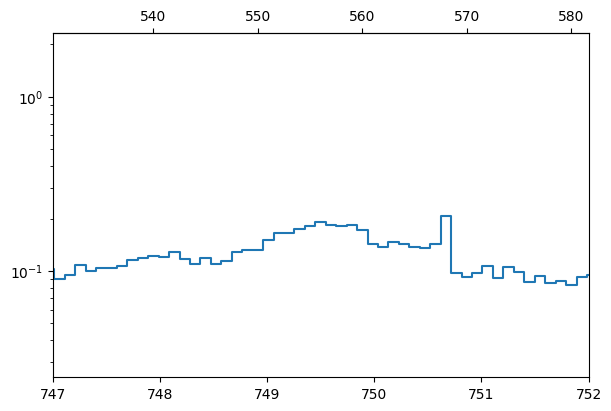

In [31]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,610:650,20], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

ax.set_xlim(747,752)
ax.set_yscale("log")
# ax.set_ylim(top=0.1)

In [32]:
MgIX_749_SIV_750_convolve_ds = np.zeros((580, 30, 30))

MgIX_749_SIV_750_convolve_kernel = Gaussian2DKernel(x_stddev=0.1, y_stddev=6)

for ii in range(30):
    MgIX_749_SIV_750_convolve_ds[:,:,ii] = convolve(sw_data[ii+545, 210:790, :], MgIX_749_SIV_750_convolve_kernel,
                                                   boundary='extend')

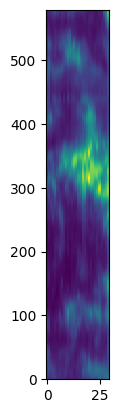

In [33]:
plt.imshow(np.nansum(MgIX_749_SIV_750_convolve_ds, axis=-1),
    origin="lower", aspect=plot_aspect,
    interpolation="none"
)

In [34]:
MgIX_749_SIV_750_fitmodel_convolve = SpectrumFit2D(
    data = MgIX_749_SIV_750_convolve_ds,
    wvl = sw_wvl_list[0][545:575],
    line_number=2,
    line_wvl_init=[749.552,750.221],
    int_max_init=[0.05,0.05],
    fwhm_init=0.5,
    same_width=True,
)

MgIX_749_SIV_750_fitmodel_convolve.run_lse_mp(ncpu=5, prev_init=False)

/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fittin

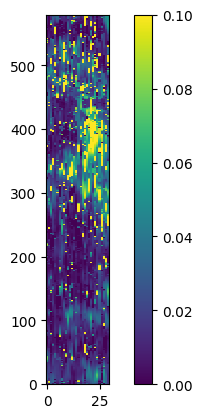

In [35]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_749_SIV_750_fitmodel_convolve.int_total_fit[:,:,0], origin='lower', aspect=plot_aspect,
vmin=0,vmax=0.1, interpolation="none")
plt.colorbar(im)

In [36]:
MgIX_749_SIV_750_rebin_ds = np.nanmean(
    sw_data[545:575,210:790,:].reshape(30, -1, 4, 30),
    axis=2
).transpose(1,2,0)

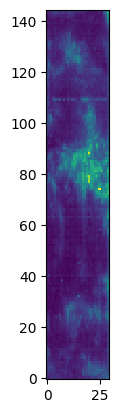

In [37]:
plt.imshow(np.nansum(MgIX_749_SIV_750_rebin_ds, axis=-1),
    origin="lower", aspect=plot_aspect*4,
    interpolation="none"
)

In [38]:
MgIX_749_SIV_750_fitmodel_rebin = SpectrumFit2D(
    data = MgIX_749_SIV_750_rebin_ds,
    wvl = sw_wvl_list[0][545:575],
    line_number=2,
    line_wvl_init=[749.552,750.221],
    int_max_init=[0.05,0.05],
    fwhm_init=0.5,
    same_width=True,
)

MgIX_749_SIV_750_fitmodel_rebin.run_lse_mp(ncpu=5, prev_init=False)

/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fittin

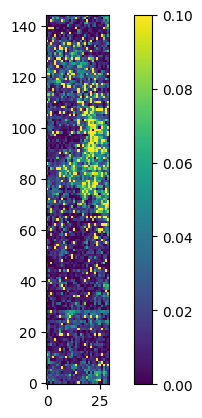

In [39]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_749_SIV_750_fitmodel_rebin.int_total_fit[:,:,0], origin='lower', aspect=plot_aspect*4,
vmin=0,vmax=0.1, interpolation="none")
plt.colorbar(im)

In [40]:
MgIX_706_749_ratio_map = MgIX_706_fitmodel.int_total_fit[:,:,0]/MgIX_749_SIV_750_fitmodel.int_total_fit[:,:,0]

/scratch/tmp.42163065.zhuyin/ipykernel_99714/2454935057.py:1: RuntimeWarning: divide by zero encountered in divide
  MgIX_706_749_ratio_map = MgIX_706_fitmodel.int_total_fit[:,:,0]/MgIX_749_SIV_750_fitmodel.int_total_fit[:,:,0]
/scratch/tmp.42163065.zhuyin/ipykernel_99714/2454935057.py:1: RuntimeWarning: invalid value encountered in divide
  MgIX_706_749_ratio_map = MgIX_706_fitmodel.int_total_fit[:,:,0]/MgIX_749_SIV_750_fitmodel.int_total_fit[:,:,0]


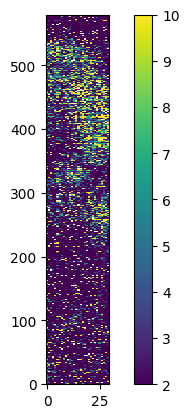

In [42]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_706_749_ratio_map,
    origin="lower", aspect=plot_aspect,
    vmin=2, vmax=10, interpolation="none"
)

plt.colorbar(im)

In [48]:
MgIX_706_749_ratio_pd = pd.read_csv("../../chianti_sav/MgIX_706_749.txt", sep=r"\s+",
    skiprows=6, skipfooter=4, header=None, names=["temp", "ratio"],
)

MgIX_706_749_ratio_pd

/scratch/tmp.42163065.zhuyin/ipykernel_99714/2591083591.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  MgIX_706_749_ratio_pd = pd.read_csv("../../chianti_sav/MgIX_706_749.txt", sep=r"\s+",


,temp,ratio
0,5.60,11.325
1,5.65,10.058
2,5.70,9.069
3,5.75,8.287
4,5.80,7.660
5,5.85,7.151
6,5.90,6.729
7,5.95,6.371
8,6.00,6.061
9,6.05,5.790


In [52]:
MgIX_706_749_ratio_func = interpolate.CubicSpline(
    np.flip(MgIX_706_749_ratio_pd["ratio"].values),
    np.flip(MgIX_706_749_ratio_pd["temp"].values),
)

In [53]:
MgIX_temp_map = MgIX_706_749_ratio_func(MgIX_706_749_ratio_map)

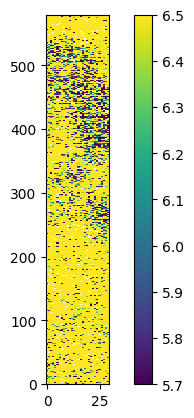

In [55]:
fig, ax = plt.subplots()
im = ax.imshow(MgIX_temp_map,
    origin="lower", aspect=plot_aspect,
    vmin=5.7, vmax=6.5, interpolation="none"
)

plt.colorbar(im)

/scratch/tmp.42163065.zhuyin/ipykernel_99714/2060507005.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,610:650,20], axis=1), where='mid')


(0.1, 0.4)

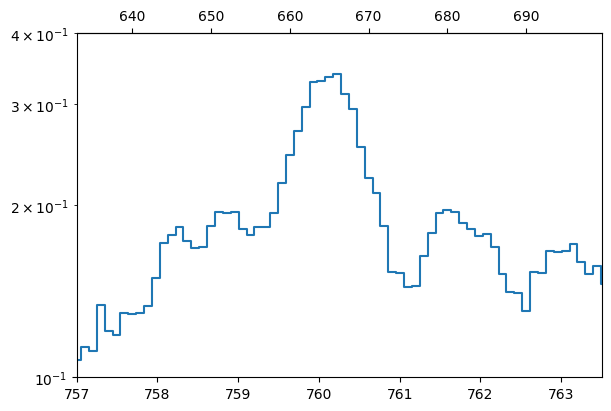

In [63]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,610:650,20], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

ax.set_xlim(757,763.5)
ax.set_yscale("log")
ax.set_ylim((0.1,0.4))


/scratch/tmp.42163065.zhuyin/ipykernel_99714/1583672794.py:2: RuntimeWarning: Mean of empty slice
  ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,550:570,20], axis=1), where='mid')


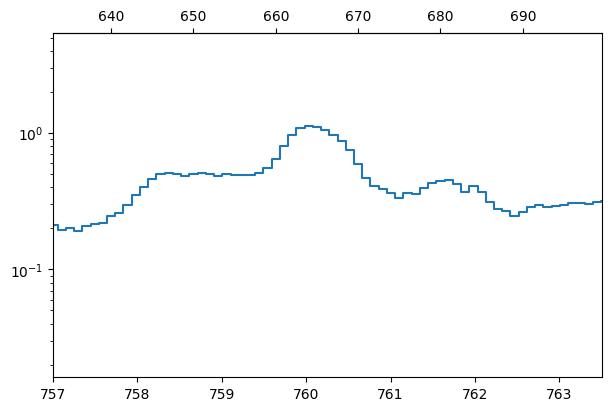

In [90]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(sw_wvl_list[0], np.nanmean(sw_data[:,550:570,20], axis=1), where='mid')

def forward(x):
    return np.interp(x, sw_wvl_list[0], np.arange(sw_data.shape[0]))

def inverse(x):
    return np.interp(x, np.arange(sw_data.shape[0]), sw_wvl_list[0])

secax = ax.secondary_xaxis('top', functions=(forward, inverse))

ax.set_xlim(757,763.5)
ax.set_yscale("log")
# ax.set_ylim((0.1,0.4))


In [67]:
OV_complex_intmap = np.nanmean(sw_data[630:700,210:790,:], axis=0)

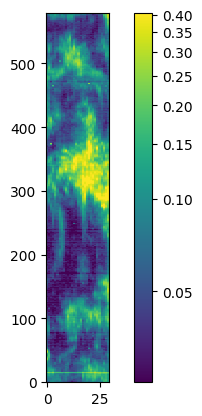

In [70]:
fig, ax = plt.subplots()
im = ax.imshow(OV_complex_intmap,
    origin="lower", aspect=plot_aspect,
    interpolation="none",
    norm=ImageNormalize(vmin=np.nanpercentile(OV_complex_intmap, 1),
                        vmax=np.nanpercentile(OV_complex_intmap, 99),
                        stretch=AsinhStretch()),
)

plt.colorbar(im)

In [97]:
def OV_complex_func(x, wvl_del, int0, int1, width, bg):
    wvl_rest1 = 758.677
    wvl_rest2 = 759.442
    int_rest2 = 1.284
    wvl_rest3 = 760.227
    int_rest3 = 1.719
    wvl_rest4 = 760.446
    int_rest4 = 0.337  
    wvl_rest5 = 761.128
    wvl_rest6 = 762.004
    int_rest6 = 1.041

    line_complex = gaussian(x, wvl_rest1 + wvl_del, int0, width) + \
        gaussian(x, wvl_rest2 + wvl_del, int0/int_rest2, width) + \
        gaussian(x, wvl_rest3 + wvl_del, int0/int_rest3, width) + \
        gaussian(x, wvl_rest4 + wvl_del, int0/int_rest4, width) + \
        gaussian(x, wvl_rest5 + wvl_del, int1, width) + \
        gaussian(x, wvl_rest6 + wvl_del, int0/int_rest6, width) + bg
    return line_complex

/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:549: UserWarning: Use custom function in the fitting. Will not plot fitted parameters.
  warn("Use custom function in the fitting. Will not plot fitted parameters.")


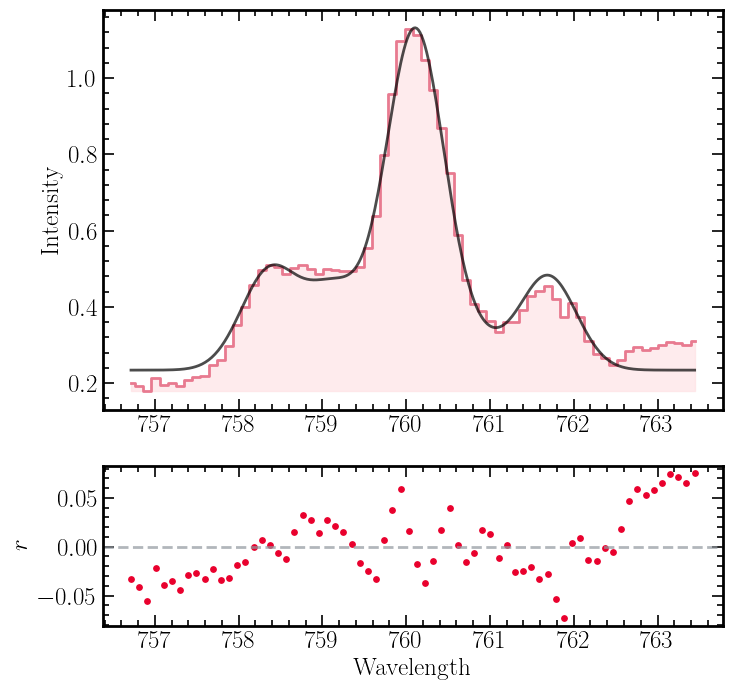

<Axes: ylabel='Intensity'>

In [98]:
OV_complex_single_fitmodel = SpectrumFitSingle(
    data=np.nanmean(sw_data[630:700,550:570,20], axis=1),
    wvl=sw_wvl_list[0][630:700],
    custom_func=OV_complex_func,
    custom_init=[-0.1, 0.1, 0.05, 0.5, 0.1]
)

OV_complex_single_fitmodel.run_lse()
OV_complex_single_fitmodel.plot()

In [99]:
OV_complex_fitmodel = SpectrumFit2D(
    data=sw_data[630:700,210:790,:].transpose(1,2,0),
    wvl=sw_wvl_list[0][630:700],
    line_number=1,
    custom_func=OV_complex_func,
    custom_init=[-0.1, 0.1, 0.05, 0.5, 0.1]
)

OV_complex_fitmodel.run_lse_mp(ncpu=5, prev_init=False)

/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:305: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(self.custom_func, self.wvl_tofit, self.data_tofit,
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input errors, absolute_sigma=False will be used in the Chi2 fitting.")
/cluster/home/zhuyin/scripts/MyPy/juanfit.py:234: UserWarning: No input errors, absolute_sigma=False will be used in the Chi2 fitting.
  warn("No input er

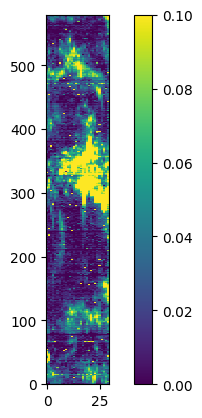

In [100]:
fig, ax = plt.subplots()
im = ax.imshow(OV_complex_fitmodel.custom_fit[:,:,1], origin='lower', aspect=plot_aspect,
vmin=0,vmax=0.1, interpolation="none")
plt.colorbar(im)

In [101]:
OV_758_761_ratio = OV_complex_fitmodel.custom_fit[:,:,1]/OV_complex_fitmodel.custom_fit[:,:,2]

/scratch/tmp.42163065.zhuyin/ipykernel_99714/3814712917.py:1: RuntimeWarning: invalid value encountered in divide
  OV_758_761_ratio = OV_complex_fitmodel.custom_fit[:,:,1]/OV_complex_fitmodel.custom_fit[:,:,2]


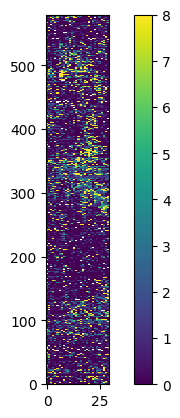

In [104]:
fig, ax = plt.subplots()
im = ax.imshow(OV_758_761_ratio, origin='lower', aspect=plot_aspect,
vmin=0,vmax=8, interpolation="none")
plt.colorbar(im)

In [106]:
OV_758_761_ratio_df = pd.read_csv("../../chianti_sav/OV_758_761.txt", sep=r"\s+",
    skiprows=6, skipfooter=4, header=None, names=["dens", "ratio"],
)

OV_758_761_ratio_df

/scratch/tmp.42163065.zhuyin/ipykernel_99714/4160677897.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  OV_758_761_ratio_df = pd.read_csv("../../chianti_sav/OV_758_761.txt", sep=r"\s+",


,dens,ratio
0,8.0,17.974
1,8.1,17.868
2,8.2,17.727
3,8.3,17.543
4,8.4,17.312
5,8.5,17.025
6,8.6,16.675
7,8.7,16.252
8,8.8,15.750
9,8.9,15.162


In [107]:
OV_758_761_ratio_func = interpolate.CubicSpline(
    np.flip(OV_758_761_ratio_df["ratio"].values),
    np.flip(OV_758_761_ratio_df["dens"].values),
)

In [108]:
OV_dens_map = OV_758_761_ratio_func(OV_758_761_ratio)

In [110]:
cmap_clip = plt.cm.viridis.copy()
cmap_clip.set_over('white')
cmap_clip.set_under('white')

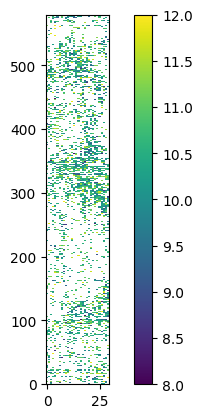

In [111]:
fig, ax = plt.subplots()
im = ax.imshow(OV_dens_map, origin='lower', aspect=plot_aspect,
vmin=8,vmax=12, interpolation="none", cmap=cmap_clip)
plt.colorbar(im)

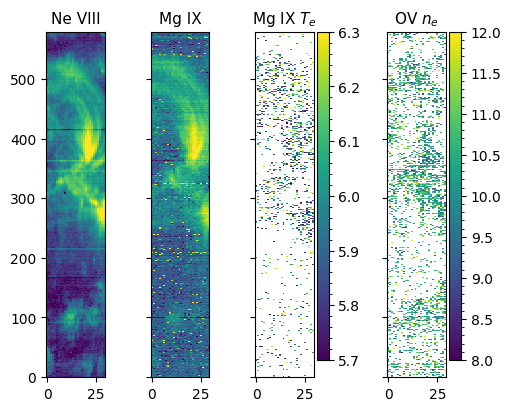

In [132]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4, figsize=(5,4), layout="constrained")
ax1.imshow(NeVIII_770_intmap, origin='lower', aspect=plot_aspect,
        norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_770_intmap, 1),
                            vmax=np.nanpercentile(NeVIII_770_intmap, 99),
                            stretch=AsinhStretch()),
        interpolation="none")
ax1.set_title("Ne VIII", fontsize=11)

ax2.imshow(MgIX_706_fitmodel.int_total_fit[:,:,0], origin='lower', aspect=plot_aspect,
        norm=ImageNormalize(vmin=np.nanpercentile(MgIX_706_fitmodel.int_total_fit, 1),
                            vmax=np.nanpercentile(MgIX_706_fitmodel.int_total_fit, 99),
                            stretch=AsinhStretch()),
        interpolation="none")
ax2.set_title("Mg IX", fontsize=11)

im3 = ax3.imshow(MgIX_temp_map, origin='lower', aspect=plot_aspect,
        vmin=5.7, vmax=6.3, interpolation="none", cmap=cmap_clip)

clb3, clb_ax3 = plot_colorbar(im3, ax=ax3, bbox_to_anchor=(1.05, 0.05, 0.2, 0.95))
ax3.set_title("Mg IX $T_e$", fontsize=11)

im4 = ax4.imshow(OV_dens_map, origin='lower', aspect=plot_aspect,
        vmin=8, vmax=12, interpolation="none", cmap=cmap_clip)

clb4, clb_ax4 = plot_colorbar(im4, ax=ax4, bbox_to_anchor=(1.05, 0.05, 0.2, 0.95))
ax4.set_title("OV $n_e$", fontsize=11)

for ax_ in (ax2,ax3,ax4):
    ax_.tick_params(labelleft=False)